ADF Statistic: -5.715111045565522
p-value: 7.150722362014598e-07
ADF Statistic after differencing: -5.808718505189647
p-value after differencing: 4.453131023060352e-07


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                 Amount   No. Observations:                   91
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1191.003
Date:                Thu, 26 Feb 2026   AIC                           2388.005
Time:                        12:24:19   BIC                           2395.505
Sample:                    03-31-2022   HQIC                          2391.029
                         - 06-29-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0417      2.367      0.018      0.986      -4.598       4.681
ma.L1         -0.0059      2.368     -0.002      0.998      -4.647       4.636
sigma2      7.722e+09   2.75e-09   2.81e+18      0.0

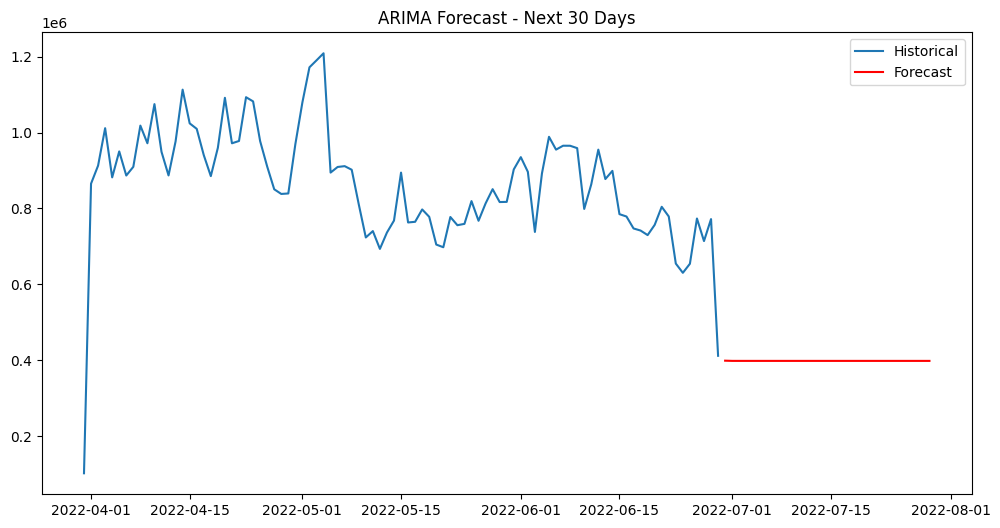

7.150722362014598e-07


In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/raw_sales.csv', low_memory=False)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

df = df.dropna(subset=["Date", "Amount"])
df = df.sort_values("Date")

daily_revenue = df.groupby("Date")["Amount"].sum()


full_dates = pd.date_range(start=daily_revenue.index.min(),
                           end=daily_revenue.index.max())

daily_revenue = daily_revenue.reindex(full_dates, fill_value=0)

daily_revenue.head()

from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_revenue)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

daily_revenue_diff = daily_revenue.diff().dropna()

result = adfuller(daily_revenue_diff)

print("ADF Statistic after differencing:", result[0])
print("p-value after differencing:", result[1])

from statsmodels.tsa.arima.model import ARIMA # type: ignore

model = ARIMA(daily_revenue, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

forecast = model_fit.forecast(steps=30)

forecast

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_revenue, label="Historical")
plt.plot(forecast.index, forecast, label="Forecast", color="red")
plt.legend()
plt.title("ARIMA Forecast - Next 30 Days")
plt.show()

result = adfuller(daily_revenue)
print(result[1])